DATASET LOADED SUCCESSFULLY

Dataset Shape:
(50000, 9)

First Five Rows
   Customer ID      Name    Surname Gender   Birthdate  Transaction Amount  \
0       752858      Sean  Rodriguez      F  2002-10-20               35.47   
1        26381  Michelle     Phelps    NaN  1985-10-24             2552.72   
2       305449     Jacob   Williams      M  1981-10-25              115.97   
3       988259    Nathan     Snyder      M  1977-10-26               11.31   
4       764762   Crystal      Knapp      F  1951-11-02               62.21   

         Date               Merchant Name     Category  
0  2023-04-03               Smith-Russell     Cosmetic  
1  2023-07-17      Peck, Spence and Young       Travel  
2  2023-09-20                  Steele Inc     Clothing  
3  2023-01-11  Wilson, Wilson and Russell     Cosmetic  
4  2023-06-13               Palmer-Hinton  Electronics  

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 

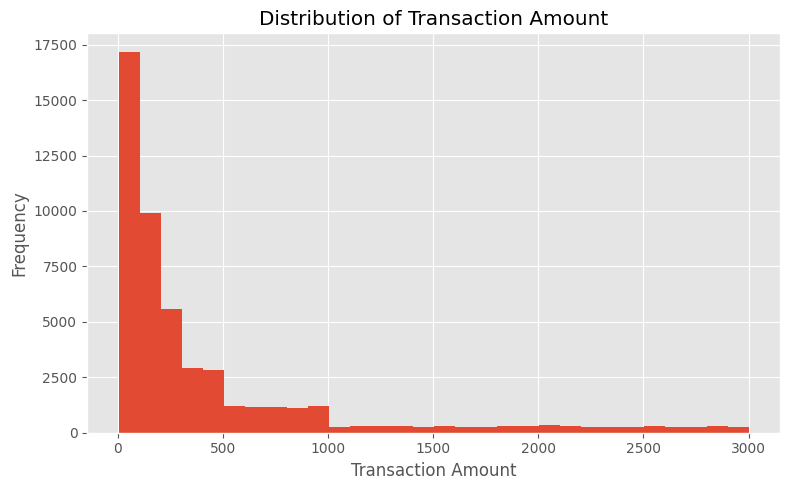

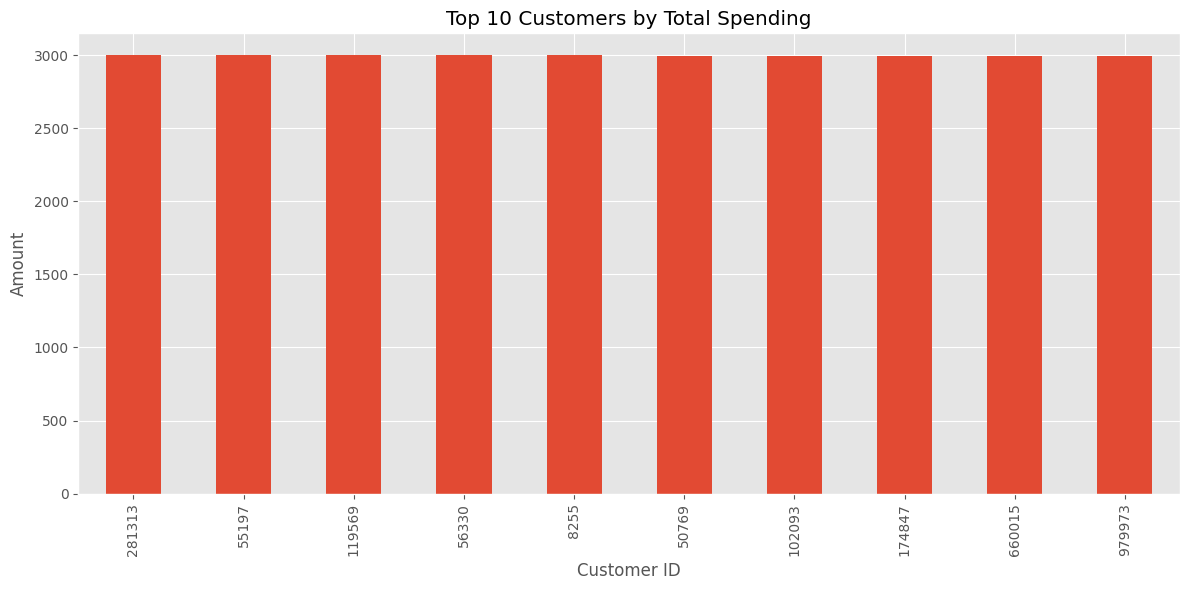

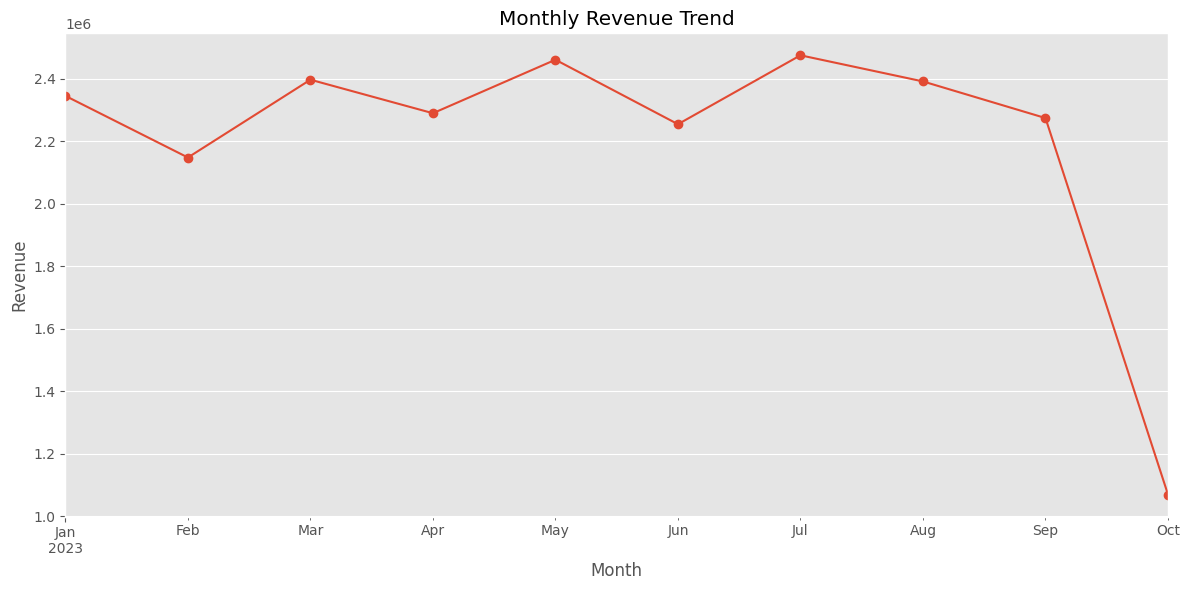


RFM ANALYSIS

RFM Table
             Recency  Frequency  Monetary
Customer ID                              
29                25          1     27.02
51               150          1   1898.56
54                82          1    166.30
83               265          1    125.85
90                27          1     18.16

RFM Statistics
            Recency  Frequency      Monetary
count  50000.000000    50000.0  50000.000000
mean     144.353960        1.0    442.119239
std       82.750902        0.0    631.669724
min        1.000000        1.0      5.010000
25%       73.000000        1.0     79.007500
50%      144.000000        1.0    182.195000
75%      216.000000        1.0    470.515000
max      287.000000        1.0   2999.880000

STANDARD SCALER
              Recency  Frequency  Monetary
Customer ID                               
29          -1.442343        0.0 -0.657153
51           0.068230        0.0  2.305723
54          -0.753521        0.0 -0.436655
83           1.457957       

AttributeError: 'KMeans' object has no attribute 'inertia'

In [1]:
# CloudExify Data Science Month 1 - FINAL PROJECT
# Customer Segmentation Analysis using RFM & K-Means

# 1. Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from datetime import timedelta

plt.style.use('ggplot')

# 2. Load Dataset

df = pd.read_csv("Customer_dataset.csv")

print("="*70)
print("DATASET LOADED SUCCESSFULLY")
print("="*70)

print("\nDataset Shape:")
print(df.shape)

print("\nFirst Five Rows")
print(df.head())

print("\nDataset Information")
print(df.info())

print("\nStatistical Summary")
print(df.describe(include='all'))

# 3. Data Cleaning

print("\n"+"="*70)
print("DATA CLEANING")
print("="*70)

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Records")
print(df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()

# Convert Date Column

df['Date'] = pd.to_datetime(df['Date'])

# Create TransactionID
# (Guide requires this column)

df['TransactionID'] = range(1, len(df)+1)

print("\nData Types")
print(df.dtypes)

# 4. Exploratory Data Analysis

print("\n"+"="*70)
print("EXPLORATORY DATA ANALYSIS")
print("="*70)

print("Total Transactions :",len(df))

print("Unique Customers :",df['Customer ID'].nunique())

print("Average Transaction Amount :",
      round(df['Transaction Amount'].mean(),2))

print("Maximum Transaction Amount :",
      round(df['Transaction Amount'].max(),2))

print("Minimum Transaction Amount :",
      round(df['Transaction Amount'].min(),2))

print("Total Revenue :",
      round(df['Transaction Amount'].sum(),2))

# 5. Basic Visualizations

# Transaction Amount Distribution

plt.figure(figsize=(8,5))
plt.hist(df['Transaction Amount'],bins=30)
plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


# Top Spending Customers

top_customers = (
    df.groupby("Customer ID")["Transaction Amount"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))
top_customers.plot(kind="bar")

plt.title("Top 10 Customers by Total Spending")
plt.xlabel("Customer ID")
plt.ylabel("Amount")
plt.tight_layout()
plt.show()


monthly_sales = (
    df.groupby(df['Date'].dt.to_period('M'))
    ['Transaction Amount']
    .sum()
)

plt.figure(figsize=(12,6))
monthly_sales.plot(marker='o')

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)

plt.tight_layout()
plt.show()

# 6. RFM ANALYSIS

print("\n"+"="*70)
print("RFM ANALYSIS")
print("="*70)

# Reference Date

reference_date = df['Date'].max() + timedelta(days=1)

# Create RFM Table

rfm = df.groupby('Customer ID').agg({

'Date':
lambda x:(reference_date-x.max()).days,

'TransactionID':'count',

'Transaction Amount':'sum'

})

rfm.columns=['Recency','Frequency','Monetary']

print("\nRFM Table")

print(rfm.head())

print("\nRFM Statistics")

print(rfm.describe())

# 7. Normalize Data

print("\n"+"="*70)
print("STANDARD SCALER")
print("="*70)

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

rfm_scaled = pd.DataFrame(

rfm_scaled,

columns=['Recency','Frequency','Monetary'],

index=rfm.index

)

print(rfm_scaled.head())

# 8. Elbow Method

print("\n"+"="*70)
print("ELBOW METHOD")
print("="*70)

inertias=[]

K=range(2,11)

for k in K:

    model=KMeans(

        n_clusters=k,

        random_state=42,

        n_init=10

    )

    model.fit(rfm_scaled)

    inertias.append(model.inertia())

plt.figure(figsize=(10,6))

plt.plot(K,inertias,'bo-')

plt.title("Elbow Method")

plt.xlabel("Number of Clusters (K)")

plt.ylabel("Inertia")

plt.grid(True)

plt.show()

print("\nChoose the elbow point from the graph.")
print("Usually K = 3 or K = 4 works well.")




K-MEANS CLUSTERING

Cluster Counts
Cluster
3    15064
2    15017
0    14980
1     4939
Name: count, dtype: int64

CLUSTER PROFILE
         Recency  Frequency  Monetary
Cluster                              
0         144.02        1.0    247.42
1         143.71        1.0   2125.65
2          48.62        1.0    263.39
3         240.33        1.0    261.93

Customer Segments
Segment
Regular Customers    15064
Loyal Customers      15017
At Risk Customers    14980
VIP Customers         4939
Name: count, dtype: int64

CUSTOMER SEGMENT PROFILE
                   Recency  Frequency  Monetary
Segment                                        
At Risk Customers   144.02        1.0    247.42
Loyal Customers      48.62        1.0    263.39
Regular Customers   240.33        1.0    261.93
VIP Customers       143.71        1.0   2125.65


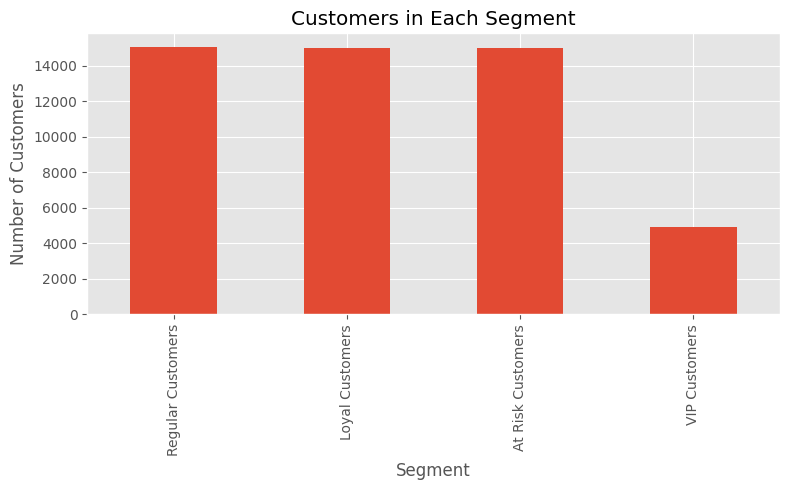

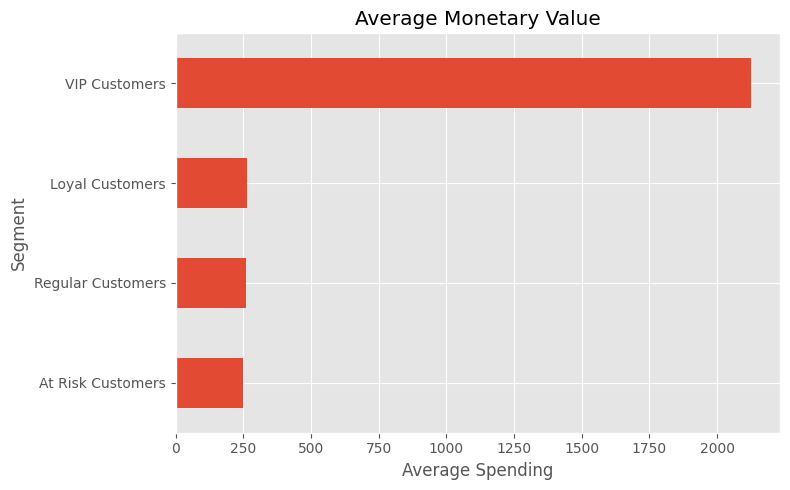

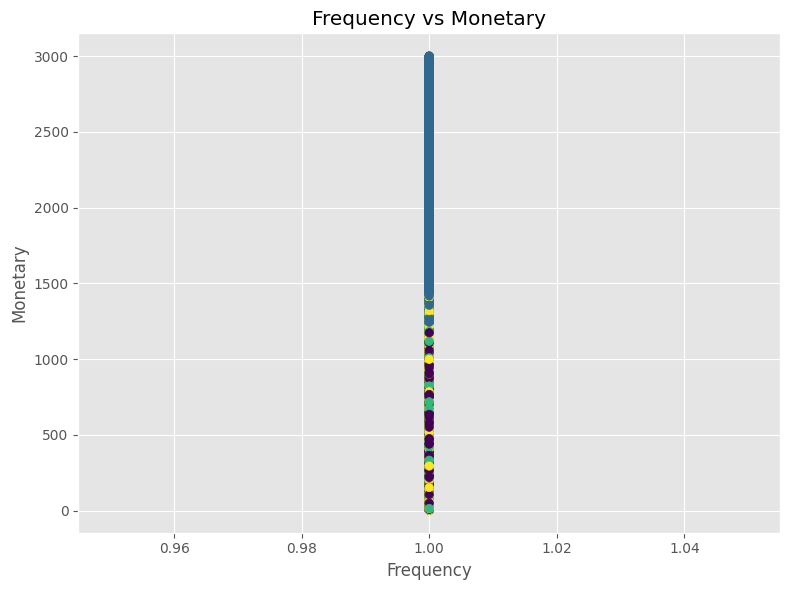

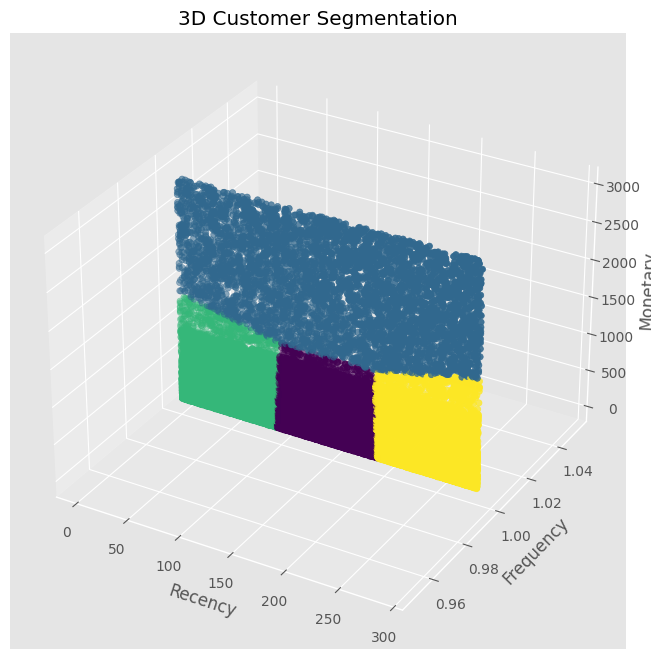


Top 10 VIP Customers
             Recency  Frequency  Monetary  Cluster        Segment
Customer ID                                                      
281313            55          1   2999.88        1  VIP Customers
55197            151          1   2999.68        1  VIP Customers
119569           181          1   2999.22        1  VIP Customers
56330            239          1   2998.51        1  VIP Customers
8255             140          1   2998.48        1  VIP Customers
50769            215          1   2997.81        1  VIP Customers
102093             6          1   2997.11        1  VIP Customers
174847           230          1   2996.86        1  VIP Customers
660015           175          1   2996.85        1  VIP Customers
979973             9          1   2996.45        1  VIP Customers

BUSINESS RECOMMENDATIONS

1. Reward VIP customers with exclusive offers.

2. Retain Loyal customers using membership programs.

3. Encourage Regular customers to purchase more
   using 

In [2]:

from mpl_toolkits.mplot3d import Axes3D

# 9. K-MEANS CLUSTERING
# 

print("\n" + "="*70)
print("K-MEANS CLUSTERING")
print("="*70)

k = 4

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

print("\nCluster Counts")
print(rfm['Cluster'].value_counts())

# 10. Cluster Summary

print("\n" + "="*70)
print("CLUSTER PROFILE")
print("="*70)

cluster_summary = rfm.groupby("Cluster").agg({
    "Recency":"mean",
    "Frequency":"mean",
    "Monetary":"mean"
}).round(2)

print(cluster_summary)

# 11. Assign Customer Segment Names

segment_names = {}

sorted_clusters = cluster_summary.sort_values(
    by="Monetary",
    ascending=False
).index.tolist()

labels = [
    "VIP Customers",
    "Loyal Customers",
    "Regular Customers",
    "At Risk Customers"
]

for c, label in zip(sorted_clusters, labels):
    segment_names[c] = label

rfm["Segment"] = rfm["Cluster"].map(segment_names)

print("\nCustomer Segments")
print(rfm["Segment"].value_counts())

# 12. Customer Segment Profile

print("\n" + "="*70)
print("CUSTOMER SEGMENT PROFILE")
print("="*70)

segment_profile = rfm.groupby("Segment").agg({
    "Recency":"mean",
    "Frequency":"mean",
    "Monetary":"mean"
}).round(2)

print(segment_profile)

# 13. Bar Chart - Customers in Each Segment

plt.figure(figsize=(8,5))

rfm["Segment"].value_counts().plot(
    kind="bar"
)

plt.title("Customers in Each Segment")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

# 14. Monetary Value by Segment

plt.figure(figsize=(8,5))

segment_profile["Monetary"].sort_values().plot(
    kind="barh"
)

plt.title("Average Monetary Value")
plt.xlabel("Average Spending")
plt.tight_layout()
plt.show()

# 15. Scatter Plot

plt.figure(figsize=(8,6))

plt.scatter(
    rfm["Frequency"],
    rfm["Monetary"],
    c=rfm["Cluster"]
)

plt.title("Frequency vs Monetary")
plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.tight_layout()
plt.show()

# 16. 3D Visualization

fig = plt.figure(figsize=(10,8))

ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    rfm["Recency"],
    rfm["Frequency"],
    rfm["Monetary"],
    c=rfm["Cluster"]
)

ax.set_xlabel("Recency")
ax.set_ylabel("Frequency")
ax.set_zlabel("Monetary")

plt.title("3D Customer Segmentation")
plt.show()

# 17. Best Customers

print("\nTop 10 VIP Customers")

vip = (
    rfm
    .sort_values("Monetary", ascending=False)
    .head(10)
)

print(vip)

# 18. Business Recommendations

print("\n" + "="*70)
print("BUSINESS RECOMMENDATIONS")
print("="*70)

print("""
1. Reward VIP customers with exclusive offers.

2. Retain Loyal customers using membership programs.

3. Encourage Regular customers to purchase more
   using personalized discounts.

4. Re-engage At Risk customers with promotional
   campaigns and reminder emails.

5. Use customer segmentation for targeted
   marketing strategies.
""")

# 19. FINAL REPORT

print("\n")
print("="*70)
print(" CUSTOMER SEGMENTATION REPORT ")
print("="*70)

print(f"Total Customers : {len(rfm)}")
print(f"Total Transactions : {len(df)}")
print(f"Total Revenue : ${df['Transaction Amount'].sum():,.2f}")
print(f"Average Transaction : ${df['Transaction Amount'].mean():,.2f}")

print("\nCustomer Segments")

print(rfm["Segment"].value_counts())

print("\nAverage RFM Values")

print(segment_profile)

print("\nTop 5 Customers by Spending")

top5 = (
    rfm
    .sort_values("Monetary", ascending=False)
    .head(5)
)

print(top5[["Frequency","Monetary","Segment"]])

print("\nKey Insights")

print("- Customer segmentation was successfully performed using RFM Analysis.")
print("- K-Means clustering grouped customers based on purchasing behavior.")
print("- VIP customers contribute the highest revenue.")
print("- At Risk customers require retention strategies.")
print("- Marketing campaigns can be personalized using customer segments.")
print("- Business resources should focus on retaining high-value customers.")

print("\nProject Completed Successfully!")

print("="*70)

